In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

%config Completer.use_jedi = False

In [2]:
from pathlib import Path
import pandas as pd

# 프로젝트 루트
BASE_DIR = Path.cwd().parent

# 데이터 경로
PREPROCESS_PATH = BASE_DIR / "data" / "processed" / "preprocessed_df.csv"

# 데이터 불러오기
df = pd.read_csv(PREPROCESS_PATH)

df.head()

,date,base_rate,unemployment,coincident,leading_price,ESI,export_price,manufacturing_capacity_utilization,economic_growth_rate,CCSI,...,broad_liquidity,deposit_rate,loan_rate,total_deposits,loans_outstanding,import_price,terms_of_income_trade,import_value,financial_account,household_credit
0,2000-01-01,4.75,5.0,46.5,50.3,NaN,141.31,108.883,1.995,NaN,...,NaN,7.15,8.59,326441.0,256737.6,75.71,37.74,32.57,-734.3,NaN
1,2000-02-01,5.00,4.8,46.7,50.5,NaN,137.81,108.079,1.995,NaN,...,NaN,7.24,8.64,343188.4,259581.8,76.03,37.17,30.85,683.0,NaN
2,2000-03-01,5.00,4.5,47.1,50.7,NaN,135.30,109.169,1.995,NaN,...,NaN,7.24,8.79,347710.3,266964.5,75.99,42.37,36.48,-402.7,NaN
3,2000-04-01,5.00,4.5,47.5,50.6,NaN,133.88,107.281,1.541,NaN,...,NaN,7.19,8.61,357049.8,277224.1,73.99,39.42,34.50,-45.3,NaN
4,2000-05-01,5.00,4.4,48.0,50.7,NaN,134.99,112.181,1.541,NaN,...,NaN,7.06,8.62,363953.3,285120.7,75.57,43.70,34.14,789.8,NaN


In [3]:
df = df.dropna()

In [4]:
df.head()

,date,base_rate,unemployment,coincident,leading_price,ESI,export_price,manufacturing_capacity_utilization,economic_growth_rate,CCSI,...,broad_liquidity,deposit_rate,loan_rate,total_deposits,loans_outstanding,import_price,terms_of_income_trade,import_value,financial_account,household_credit
115,2009-08-01,2.0,3.9,71.9,69.7,105.2,129.76,107.441,3.051,118.3,...,2383597.7,3.07,5.61,717468.9,956229.6,119.86,59.97,70.30,2434.8,754189.6
116,2009-09-01,2.0,3.6,72.2,70.0,108.7,127.41,111.630,3.051,117.8,...,2390541.5,3.33,5.82,735366.3,958578.1,117.54,66.70,75.51,1745.8,754189.6
117,2009-10-01,2.0,3.6,72.6,70.6,111.2,123.54,110.096,0.732,123.0,...,2397783.9,3.51,5.88,740219.1,958048.5,116.25,66.29,78.17,4525.3,775985.3
118,2009-11-01,2.0,3.7,72.9,71.2,113.0,123.83,110.634,0.732,118.1,...,2410678.8,3.54,5.87,747499.5,963885.1,118.49,65.00,74.94,3929.4,775985.3
119,2009-12-01,2.0,3.6,73.1,71.6,114.3,124.84,111.591,0.732,116.5,...,2420301.2,3.70,5.81,751272.7,953505.2,119.10,66.78,84.16,1535.4,775985.3


In [5]:
# 날짜형 변환
df["date"] = pd.to_datetime(df["date"])

# date를 index로 설정
df = (
    df.sort_values("date")
      .set_index("date")
)

In [6]:
LAGS = [1,3,6]

# 결과 저장용 DataFrame
feature_df = pd.DataFrame(index=df.index)

# 1. 기준금리 자기 자신의 lag 생성
for lag in LAGS:
    feature_df[f"base_rate_lag{lag}"] = df["base_rate"].shift(lag)

# 2. 경제지표 lag 생성
feature_cols = [col for col in df.columns if col != "base_rate"]

for col in feature_cols:
    for lag in LAGS:
        feature_df[f"{col}_lag{lag}"] = df[col].shift(lag)

# 3. 다음 달 기준금리를 target으로 생성
feature_df["target"] = df["base_rate"].shift(-1)

# 4. 결측치 제거
feature_df = feature_df.dropna()

feature_df.head()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18100\3059721875.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[f"{col}_lag{lag}"] = df[col].shift(lag)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18100\3059721875.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[f"{col}_lag{lag}"] = df[col].shift(lag)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18100\3059721875.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.in

,base_rate_lag1,base_rate_lag3,base_rate_lag6,unemployment_lag1,unemployment_lag3,unemployment_lag6,coincident_lag1,coincident_lag3,coincident_lag6,leading_price_lag1,...,import_value_lag1,import_value_lag3,import_value_lag6,financial_account_lag1,financial_account_lag3,financial_account_lag6,household_credit_lag1,household_credit_lag3,household_credit_lag6,target
date,,,,,,,,,,,,,,,,,,,,,
2010-02-01,2.0,2.0,2.0,4.7,3.7,3.9,73.4,72.9,71.9,71.9,...,81.10,74.94,70.30,1181.8,3929.4,2434.8,783323.6,775985.3,754189.6,2.00
2010-03-01,2.0,2.0,2.0,4.0,3.6,3.6,74.0,73.1,72.2,71.9,...,79.50,84.16,75.51,-1560.1,1535.4,1745.8,783323.6,775985.3,754189.6,2.00
2010-04-01,2.0,2.0,2.0,3.6,4.7,3.6,74.6,73.4,72.6,71.9,...,91.34,81.10,78.17,327.7,1181.8,4525.3,783323.6,783323.6,775985.3,2.00
2010-05-01,2.0,2.0,2.0,3.6,4.0,3.7,75.0,74.0,72.9,72.0,...,91.02,79.50,74.94,-2308.1,-1560.1,3929.4,800126.9,783323.6,775985.3,2.00
2010-06-01,2.0,2.0,2.0,3.3,3.6,3.6,75.5,74.6,73.1,72.2,...,89.18,91.34,84.16,4537.5,327.7,1535.4,800126.9,783323.6,775985.3,2.25


In [7]:
lag_summary = []
selected_features = []

feature_columns = [col for col in feature_df.columns if col != "target"]

base_features = sorted(set(
    col.rsplit("_lag", 1)[0]
    for col in feature_columns
    if "_lag" in col
))

for base_feature in base_features:
    candidates = []

    for lag in LAGS:
        feature_name = f"{base_feature}_lag{lag}"

        if feature_name in feature_df.columns:
            corr = feature_df[[feature_name, "target"]].corr().iloc[0, 1]

            candidates.append({
                "base_feature": base_feature,
                "selected_feature": feature_name,
                "lag": lag,
                "corr": corr,
                "abs_corr": abs(corr)
            })

    if candidates:
        best = max(candidates, key=lambda x: x["abs_corr"])

        selected_features.append(best["selected_feature"])
        lag_summary.append(best)

lag_summary_df = pd.DataFrame(lag_summary).sort_values(
    "abs_corr",
    ascending=False
)

lag_summary_df

,base_feature,selected_feature,lag,corr,abs_corr
5,base_rate,base_rate_lag1,1,0.980246,0.980246
14,deposit_rate,deposit_rate_lag1,1,0.961972,0.961972
29,loan_rate,loan_rate_lag1,1,0.890473,0.890473
22,import_price,import_price_lag6,6,0.875108,0.875108
17,export_price,export_price_lag6,6,0.854390,0.854390
27,land_price_change,land_price_change_lag1,1,-0.740749,0.740749
40,unemployment,unemployment_lag3,3,-0.726480,0.726480
38,terms_of_trade,terms_of_trade_lag1,1,-0.669577,0.669577
4,PPI,PPI_lag6,6,0.581835,0.581835
23,import_value,import_value_lag6,6,0.507130,0.507130


In [8]:
# 최적 Lag Feature만 사용한 데이터셋 생성
#feature_df_best_lag = feature_df[selected_features + ["target"]].copy()

#feature_df_best_lag.head()

In [10]:
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

feature_df.to_csv(
    PROCESSED_DIR / "feature_df.csv",
    encoding="utf-8-sig"
)

print("feature_df.csv 저장 완료")

feature_df.csv 저장 완료


In [172]:
import numpy as np
#X = feature_df_best_lag.drop(columns=["target"])
#y = feature_df_best_lag["target"]


X = feature_df.drop(columns=["target"])
y = feature_df["target"]

X_train = X.iloc[:-12]
X_test = X.iloc[-12:]

y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(179, 132)
(12, 132)
(179,)
(12,)


In [150]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [151]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=8, min_samples_leaf=3, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [152]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 모델 성능 평가 함수
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Train R²": round(r2_score(y_train, y_train_pred), 4),
        "Test R²": round(r2_score(y_test, y_test_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 4),
        "MAE": round(mean_absolute_error(y_test, y_test_pred), 4)
    }

In [153]:
rf_result = evaluate_model(
    rf_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

In [154]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [155]:
xgb_result = evaluate_model(
    xgb_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

In [156]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train_scaled, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7185
[LightGBM] [Info] Number of data points in the train set: 179, number of used features: 132
[LightGBM] [Info] Start training from score 2.082402
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=3,
              min_child_samples=5, n_estimators=200, n_jobs=-1, num_leaves=15,
              random_state=42, subsample=0.8)

In [157]:
lgbm_result = evaluate_model(
    lgbm_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

In [158]:
print(rf_result)
print(xgb_result)
print(lgbm_result)

{'Train R²': 0.9947, 'Test R²': -0.1783, 'RMSE': 0.1011, 'MAE': 0.0826}
{'Train R²': 0.9998, 'Test R²': -0.84, 'RMSE': 0.1264, 'MAE': 0.0975}
{'Train R²': 0.9997, 'Test R²': -3.6525, 'RMSE': 0.201, 'MAE': 0.1889}


In [159]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(
    "feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

importance

,feature,importance
105,deposit_rate_lag1,0.494258
0,base_rate_lag1,0.288018
108,loan_rate_lag1,0.115976
119,import_price_lag6,0.024694
14,ESI_lag6,0.014447
...,...,...
42,GDP_lag1,0.000024
21,economic_growth_rate_lag1,0.000022
57,industrial_production_lag1,0.000019
90,manufacturing_output_lag1,0.000015


In [160]:
# 중요도 기준 설정
THRESHOLD = 0.001

# 중요도 기준 이상만 선택
selected = importance[importance["importance"] >= THRESHOLD].copy()

# 원본 변수명 추출 (예: import_price_lag3 -> import_price)
selected["base_feature"] = selected["feature"].str.replace(
    r"_lag\d+$", "", regex=True
)

# 같은 변수는 가장 높은 importance 하나만 선택
selected = (
    selected
    .sort_values("importance", ascending=False)
    .drop_duplicates(subset="base_feature", keep="first")
)

# 최종 선택된 변수
top_features = selected["feature"].tolist()

print(f"선택된 변수 개수 : {len(top_features)}")
print(top_features)

# 새로운 데이터셋 생성
X = feature_df[top_features]
y = feature_df["target"]

선택된 변수 개수 : 11
['deposit_rate_lag1', 'base_rate_lag1', 'loan_rate_lag1', 'import_price_lag6', 'ESI_lag6', 'retail_sales_lag6', 'PPI_lag1', 'export_price_lag6', 'CCSI_lag3', 'manufacturing_capacity_utilization_lag6', 'us_policy_rate_lag6']


In [161]:
# Train / Test 분할
X_train = X.iloc[:-12]
X_test = X.iloc[-12:]

y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(179, 11)
(12, 11)
(179,)
(12,)


하이퍼 파라미터 튜닝

In [162]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 시계열 분할
tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [10, 15, 20, 30],
    "min_samples_leaf": [5, 8, 10, 15],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "bootstrap": [True]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best Params:")
print(search.best_params_)

best_rf_model = search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [2, 3, 4, 5],
                                        'max_features': ['sqrt', 'log2', 0.3,
                                                         0.5],
                                        'min_samples_leaf': [5, 8, 10, 15],
                                        'min_samples_split': [10, 15, 20, 30],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

Best Params:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 3, 'bootstrap': True}


In [163]:
# 평가
best_rf_result = evaluate_model(
    best_rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

In [164]:
print("Before:", rf_result)
print("After :", best_rf_result)

Before: {'Train R²': 0.9947, 'Test R²': -0.1783, 'RMSE': 0.1011, 'MAE': 0.0826}
After : {'Train R²': 0.9846, 'Test R²': -0.9221, 'RMSE': 0.1292, 'MAE': 0.0876}


기준금리는 일정 기간 동안 동일한 수준이 유지되는 특성이 있어 테스트 구간의 분산이 매우 작았다. 이로 인해 R²는 낮게 나타났으나, 실제 예측 오차(RMSE≈0.10, MAE≈0.08)는 작아 모델이 기준금리 수준을 비교적 안정적으로 예측함을 확인하였다.

In [173]:
final_model = rf_model
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
105,deposit_rate_lag1,0.494258
0,base_rate_lag1,0.288018
108,loan_rate_lag1,0.115976
119,import_price_lag6,0.024694
14,ESI_lag6,0.014447
106,deposit_rate_lag3,0.009853
109,loan_rate_lag3,0.008593
117,import_price_lag1,0.004704
118,import_price_lag3,0.004346
80,retail_sales_lag6,0.004186


<Figure size 1000x800 with 0 Axes>

<BarContainer object of 20 artists>

Text(0.5, 0, 'Feature Importance')

Text(0.5, 1.0, 'Top 20 Feature Importance')

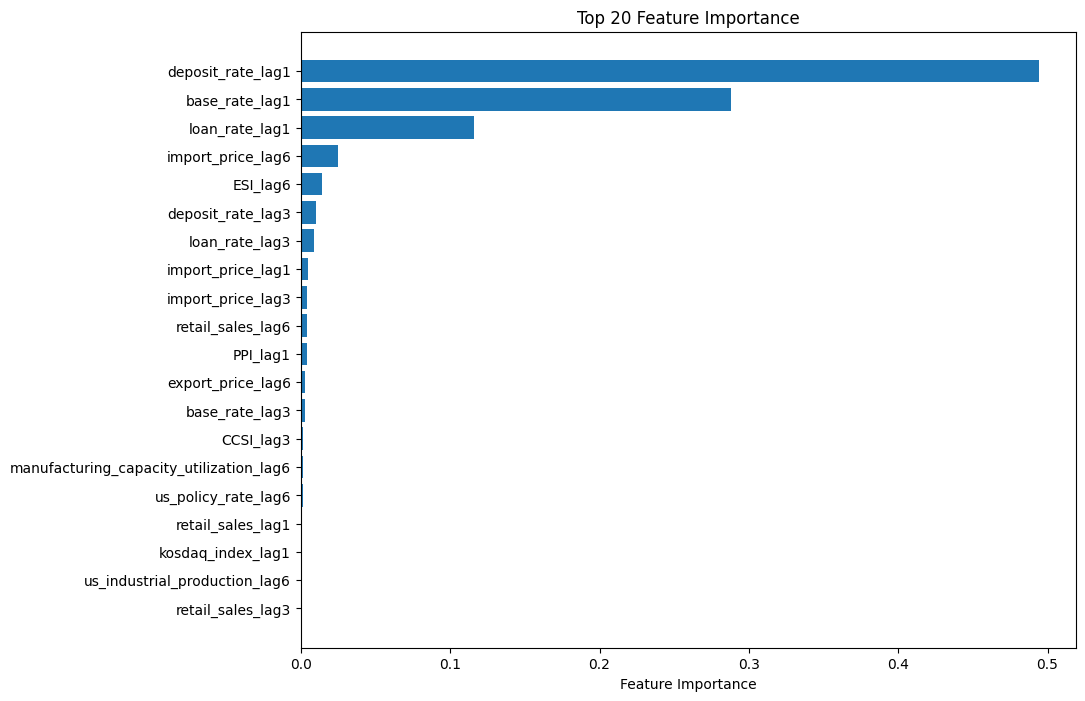

In [174]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top20["feature"], top20["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importance")
plt.show()

C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


<Figure size 1200x500 with 0 Axes>

Text(0.5, 1.0, 'Base Rate Prediction')

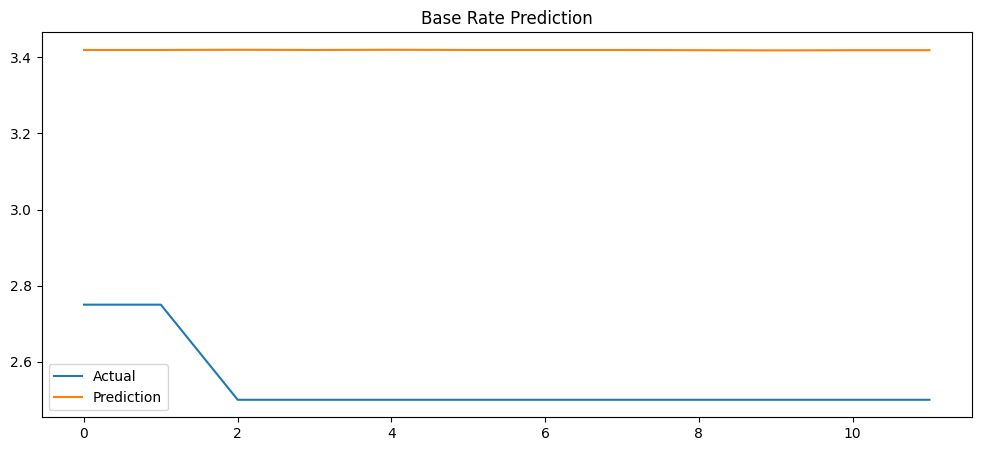

In [175]:
y_pred = final_model.predict(X_test)

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Prediction")

plt.legend()
plt.title("Base Rate Prediction")
plt.show()

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 'Prediction')

Text(0, 0.5, 'Residual')

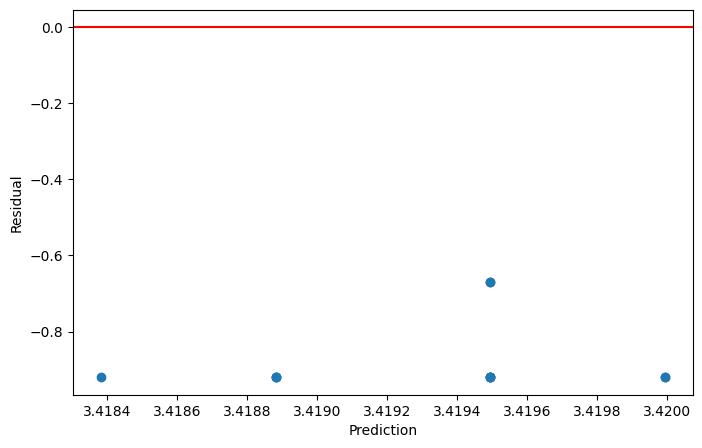

In [176]:
residual = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residual)
plt.axhline(0, color="red")
plt.xlabel("Prediction")
plt.ylabel("Residual")
plt.show()

In [ ]:
# 모델 저장
MODEL_PATH = BASE_DIR / "model"
MODEL_PATH.mkdir(exist_ok=True)

joblib.dump(final_model, MODEL_PATH / "rf_base_rate.pkl")

['rf_base_rate.pkl']